Notebook for results

In [17]:
#Import libraries

#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp
import json

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
temporary_outpath = './'
adatas_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/


In [18]:
gr_annotations_df = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

In [22]:
adata = anndata.read_h5ad('/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas/adata_leiden.h5ad') 

gr_annotations = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

df_annotations = gr_annotations.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]


df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])


In [ ]:
#SORT ADATA OBJECT (already sorted)

# Merge Chromosome and End information into adata.var
# adata.var = adata.var.merge(gr_annotations_df[['ensembl_gene_id', 'Chromosome', 'End']], 
#                             on='ensembl_gene_id', how='left')

# print(adata.var.columns)

# adata.var['Chromosome'] = adata.var['Chromosome'].astype(str)  # Convert Chromosome to string

# # Sort adata.var by Chromosome and End
# sorted_var = adata.var.sort_values(by=['Chromosome', 'End'])

# # Reorder adata.X columns based on the sorted var index
# adata = adata[:, sorted_var.index]

In [ ]:
chr_var_names = dict()
for chromosome in df_exp_annotations_sorted['Chromosome'].unique():
    chr_var_names[chromosome] = df_exp_annotations_sorted.query(f' Chromosome=="{chromosome}" ')\
                                .sort_values('Start')['ensembl_gene_id'].values

# Load the JSON file as a dictionary
json_file_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/chromosome_stops.json'
with open(json_file_path, 'r') as file:
    chromosome_stops = json.load(file)

#sort the dictionary by values
chromosome_stops = {k: v for k, v in sorted(chromosome_stops.items(), key=lambda item: item[1])}
chromosome_stops = {np.str_(k): np.int64(v) for k, v in chromosome_stops.items()}

# Use chromosome_stops directly without further processing

chromosome_stops_list = sorted(list(chromosome_stops.values()))

#add 0 to the list and the adata shape -1 
chromosome_stops_list = [np.int64(0)] + sorted(list(chromosome_stops.values())) + [np.int64(adata.shape[1]-1)]
print("Fixed chromosome_stops_list with consistent types:")
print(chromosome_stops_list)

# Check data types to confirm consistency
print("\nData types of first and last elements:")
print(f"First element type: {type(chromosome_stops_list[0])}")
print(f"Middle element type: {type(chromosome_stops_list[10])}")
print(f"Last element type: {type(chromosome_stops_list[-1])}")

[0, np.int64(218), np.int64(2859), np.int64(3508), np.int64(4457), np.int64(5335), np.int64(6090), np.int64(6370), np.int64(7179), np.int64(8215), np.int64(8612), np.int64(9783), np.int64(10119), np.int64(11024), np.int64(11571), np.int64(12091), np.int64(12519), np.int64(13423), np.int64(14172), np.int64(15474), np.int64(15845), np.int64(16110), np.int64(16505), np.int64(16700), np.int64(17151), 17152]


In [ ]:
# Visualize chromosome regions and their sizes
chromosome_names = list(chromosome_stops.keys())
chromosome_sizes = [chromosome_stops_list[i+1] - chromosome_stops_list[i] for i in range(len(chromosome_stops_list)-1)]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(chromosome_sizes)), chromosome_sizes)

# Add chromosome labels where they fit
plt.xlabel('Chromosome Index')
plt.ylabel('Size (number of genes)')
plt.title('Chromosome Sizes in Gene Count')
plt.xticks(range(0, len(chromosome_sizes), 2))

# Add actual chromosome names as annotations for the major chromosomes
for i, name in enumerate(chromosome_names):
    if chromosome_sizes[i] > 500:  # Only label larger chromosomes to avoid clutter
        plt.text(i, chromosome_sizes[i]/2, name, ha='center', va='center')

plt.tight_layout()
plt.show()

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
1

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 15.9831
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 6170 is added to all_max_ids.
Index of the maximum 6979 is added to all_max_ids.
Index of the maximum 8015 is added to all_max_ids.


...

Index of the maximum 3908 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Index of the maximum 14195 is added to all_max_ids.
Index of the maximum 600 is added to all_max_ids.
Index of the maximum 1063 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 2001 is added to all_max_ids.
Index of the maximum 2111 is added to all_max_ids.
Index of the maximum 2222 is added to all_max_ids.
Index of the maximum 16717 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.


no breakpoints are found within the interval: (3109,3228)


Index of the maximum 3028 is added to all_max_ids.


no breakpoints are found within the interval: (7060,7165)


Index of the maximum 7245 is added to all_max_ids.
Index of the maximum 3736 is added to all_max_ids.
Index of the maximum 12905 is added to all_max_ids.
Found 65 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ordered segmented region sizes to file...
Segmented region sizes are written to file


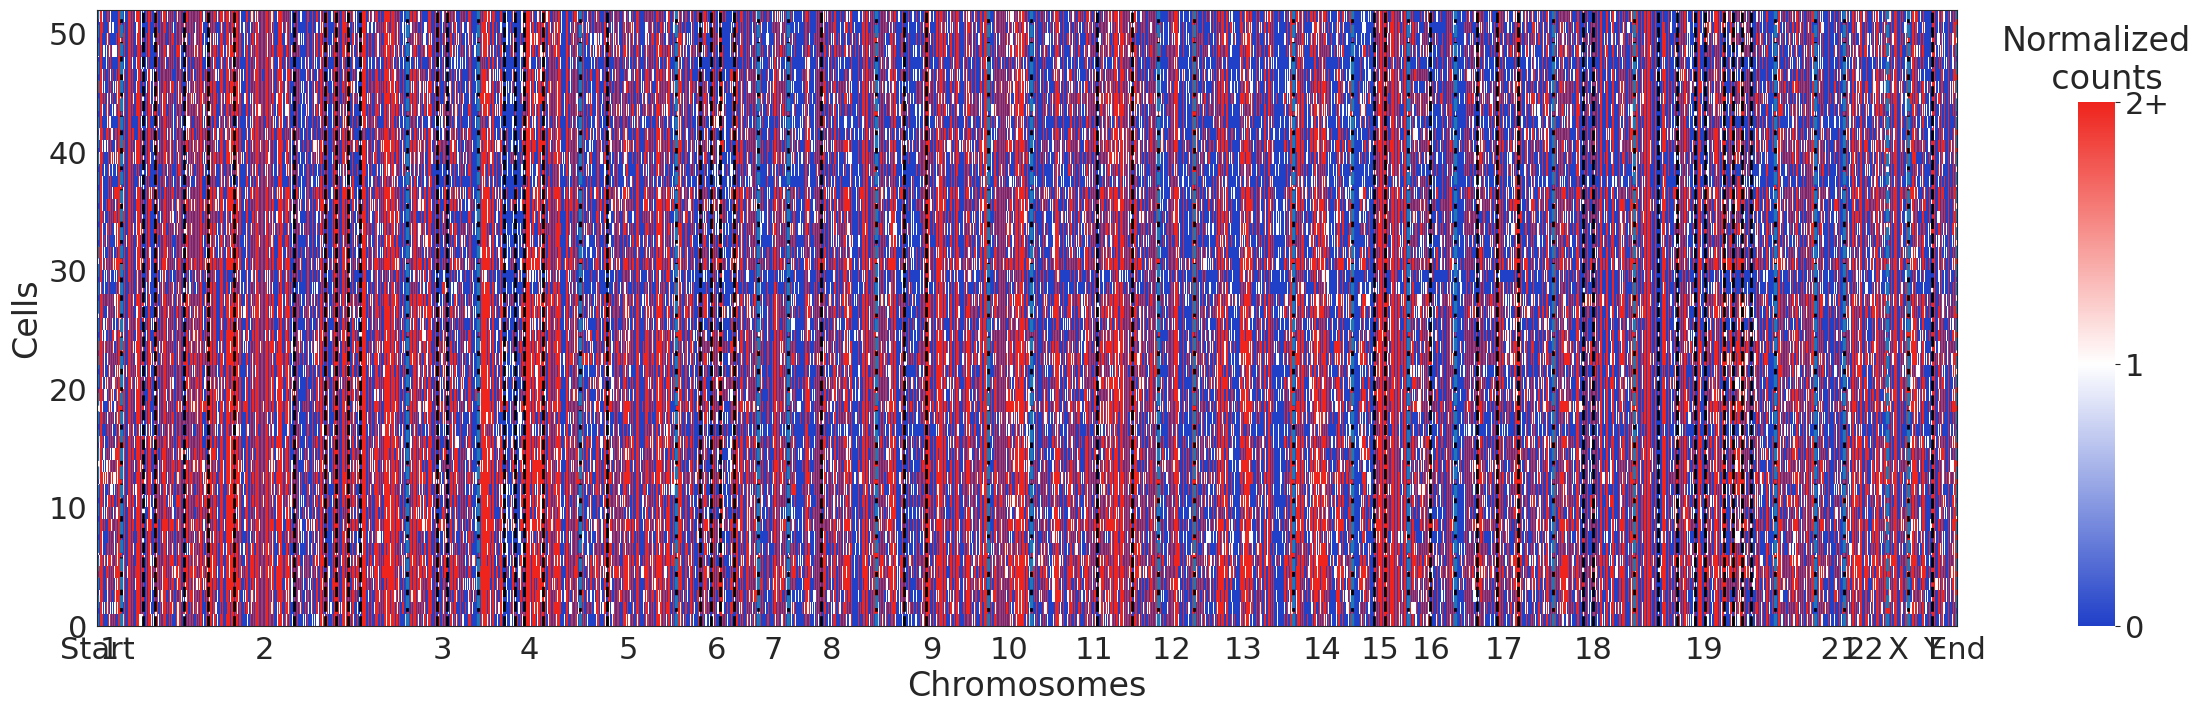

Condensing regions...
Done.
Learning cluster tree...
n_neighbours to be used: 5
Setting min_cluster_size to 1
Finding 5 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.21440601348876953 seconds
Jaccard graph constructed in 0.011250734329223633 seconds
Wrote graph to binary file in 0.0026979446411132812 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.665847
After 5 runs, maximum modularity is Q = 0.669633
Louvain completed 25 runs in 0.17988872528076172 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7608366012573242 seconds
Found 6 clusters.
Cluster sizes: [12. 10.  9.  8.  7.  6.]
Creating ./rep0_try0_PYSCICONETREETEMP_PYSCICONETEMP...
Created ./rep0_try0_PYSCICONETREETEMP_PYSCICONETEMP!
Trying to move to ./rep0_try0_PYSCICONETREETEMP_PYSCICONETEMP with os.chdir
Creating temporary files...
Creating ./rep1_try0_PYSCICONETREETEMP_PYSCICONETEMP...
Created ./rep1_try0_PYSCICONETR

KeyboardInterrupt: 

In [21]:
file_list = ['clusters_median', 'clusters_mean', 'clusters_sum', 'clusters_mean_transformed',
             'clusters_sum_transformed', 'clusters_median_transformed', 'adata_clustered_norm']
for cluster_file in file_list:
    #for window_size in range(100, 1000, 100):
            try:
                adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
                data = adata.X
                # Run SCICoNE analysis
                bps = sci.detect_breakpoints(data=data, window_size=200, threshold=3, input_breakpoints=chromosome_stops_list)

                # Save the matrix plot
                matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
                scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                                chr_stops_dict=chromosome_stops,
                                                cbar_title='Normalized\n  counts', vmax=2, cluster=False)

                # plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
                # plt.close()

                # Learn and save the tree plot
                
                inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
                inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

                tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}.png"
                # Render the tree plot using graphviz's render method

                # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
                # print(f"Tree plot saved to {tree_plot_filename}.png")

            except ValueError as ve:
                print(f"ValueError while processing the cluster file: {ve}")
            except Exception as e:
                print(f"An error occurred while processing the cluster file: {e}")
                continue

In [ ]:
cluster_file_1 = 'clusters_mean'
cluster_file_2 = 'clusters_median'
cluster_file_3 = 'clusters_sum'
cluster_file_4 = 'clusters_mean_transformed'
cluster_file_5 = 'clusters_sum_transformed'
cluster_file_6 = 'clusters_median_transformed'
cluster_file_7 = 'adata_clustered_norm'
cluster_file_8 = 'adata_clusters_sum'

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 15.9831
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157,

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 8015 is added to all_max_ids.
Index of the maximum 8412 is added to all_max_ids.


no breakpoints are found within the interval: (8096,8332)


Index of the maximum 9583 is added to all_max_ids.
Index of the maximum 9919 is added to all_max_ids.


...

Index of the maximum 15004 is added to all_max_ids.
Index of the maximum 5540 is added to all_max_ids.
Index of the maximum 3654 is added to all_max_ids.
Index of the maximum 11674 is added to all_max_ids.
Index of the maximum 5456 is added to all_max_ids.
Index of the maximum 11572 is added to all_max_ids.


no breakpoints are found within the interval: (13304,13423)


Index of the maximum 13503 is added to all_max_ids.
Index of the maximum 5683 is added to all_max_ids.
Index of the maximum 9344 is added to all_max_ids.
Index of the maximum 6475 is added to all_max_ids.
Index of the maximum 14900 is added to all_max_ids.
Index of the maximum 7447 is added to all_max_ids.
Index of the maximum 14818 is added to all_max_ids.
Index of the maximum 14627 is added to all_max_ids.
Index of the maximum 14368 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 3553 is added to all_max_ids.


no breakpoints are found within the interval: (3389,3473)


Index of the maximum 852 is added to all_max_ids.
Index of the maximum 12707 is added to all_max_ids.
Index of the maximum 12519 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 1993 is added to all_max_ids.
Index of the maximum 13591 is added to all_max_ids.
Index of the maximum 12095 is added to all_max_ids.
Index of the maximum 603 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 6780 is added to all_max_ids.
Index of the maximum 4655 is added to all_max_ids.
Index of the maximum 4770 is added to all_max_ids.
Index of the maximum 4854 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Found 55 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ord

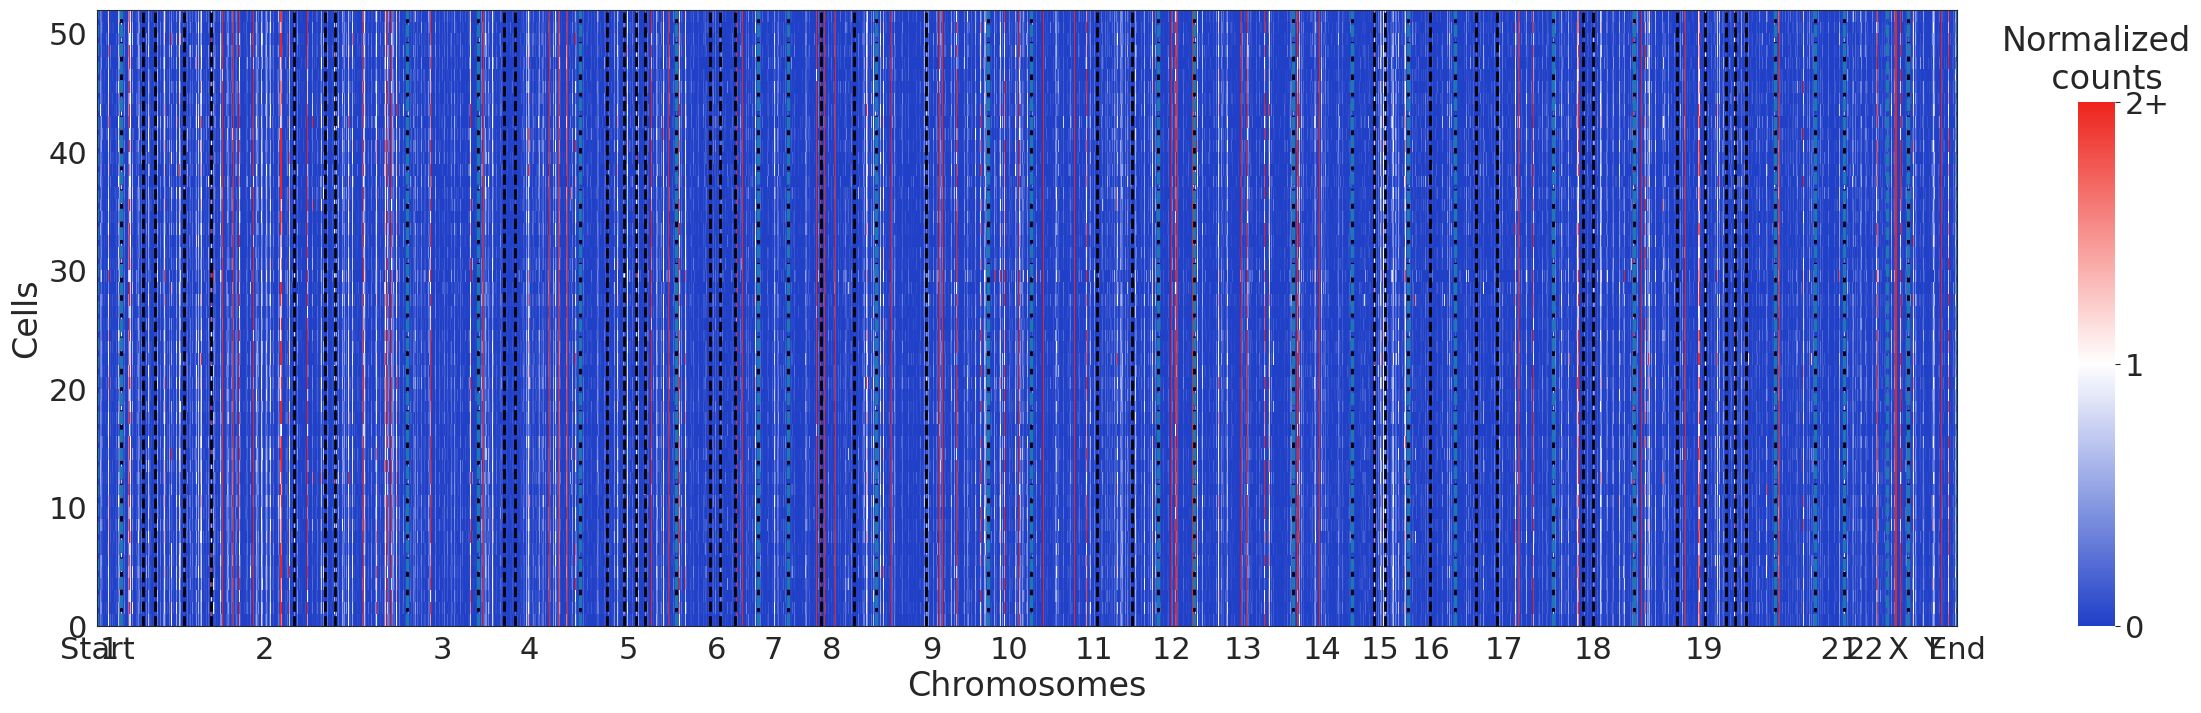

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
1

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00681768
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 12.4559
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 8015 is added to all_max_ids.
Index of the maximum 8412 is added to all_max_ids.
Index of the maximum 9583 is added to all_max_ids.


...

Index of the maximum 2935 is added to all_max_ids.
Index of the maximum 3908 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Index of the maximum 14195 is added to all_max_ids.
Index of the maximum 600 is added to all_max_ids.
Index of the maximum 1063 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 2001 is added to all_max_ids.
Index of the maximum 2111 is added to all_max_ids.
Index of the maximum 2222 is added to all_max_ids.
Index of the maximum 16717 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.


no breakpoints are found within the interval: (3109,3228)


Index of the maximum 3028 is added to all_max_ids.


no breakpoints are found within the interval: (7060,7165)


Index of the maximum 7245 is added to all_max_ids.
Index of the maximum 3736 is added to all_max_ids.
Index of the maximum 12905 is added to all_max_ids.
Found 65 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ordered segmented region sizes to file...
Segmented region sizes are written to file


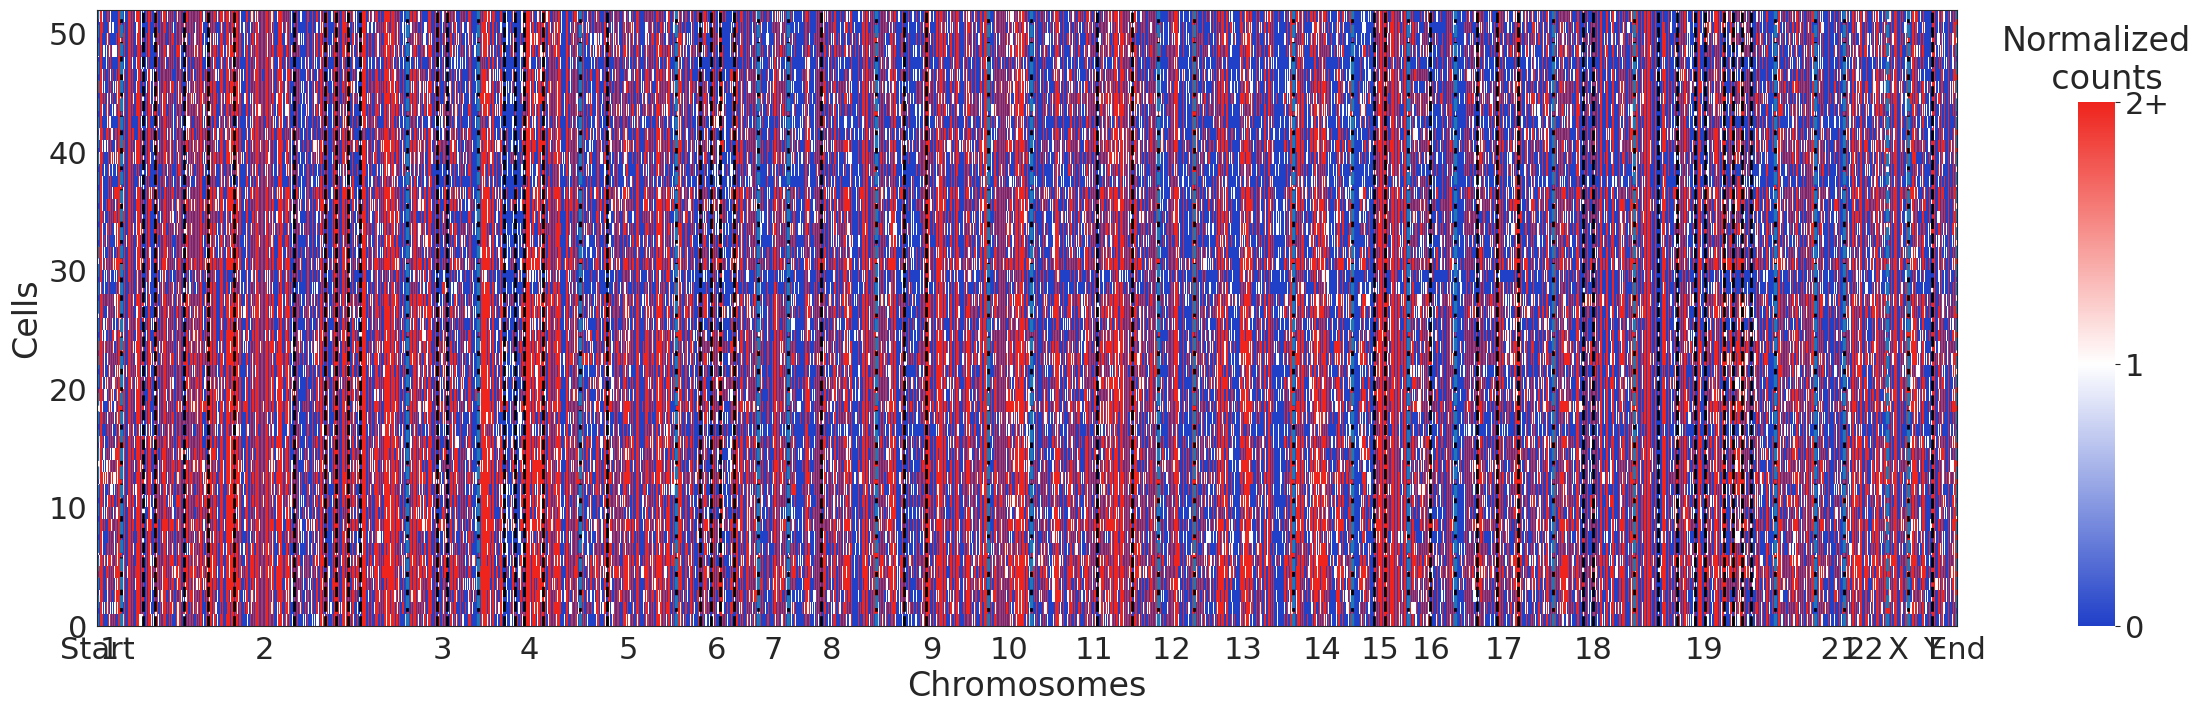

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.913692
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.674027
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 95.9899
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.917301
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
16

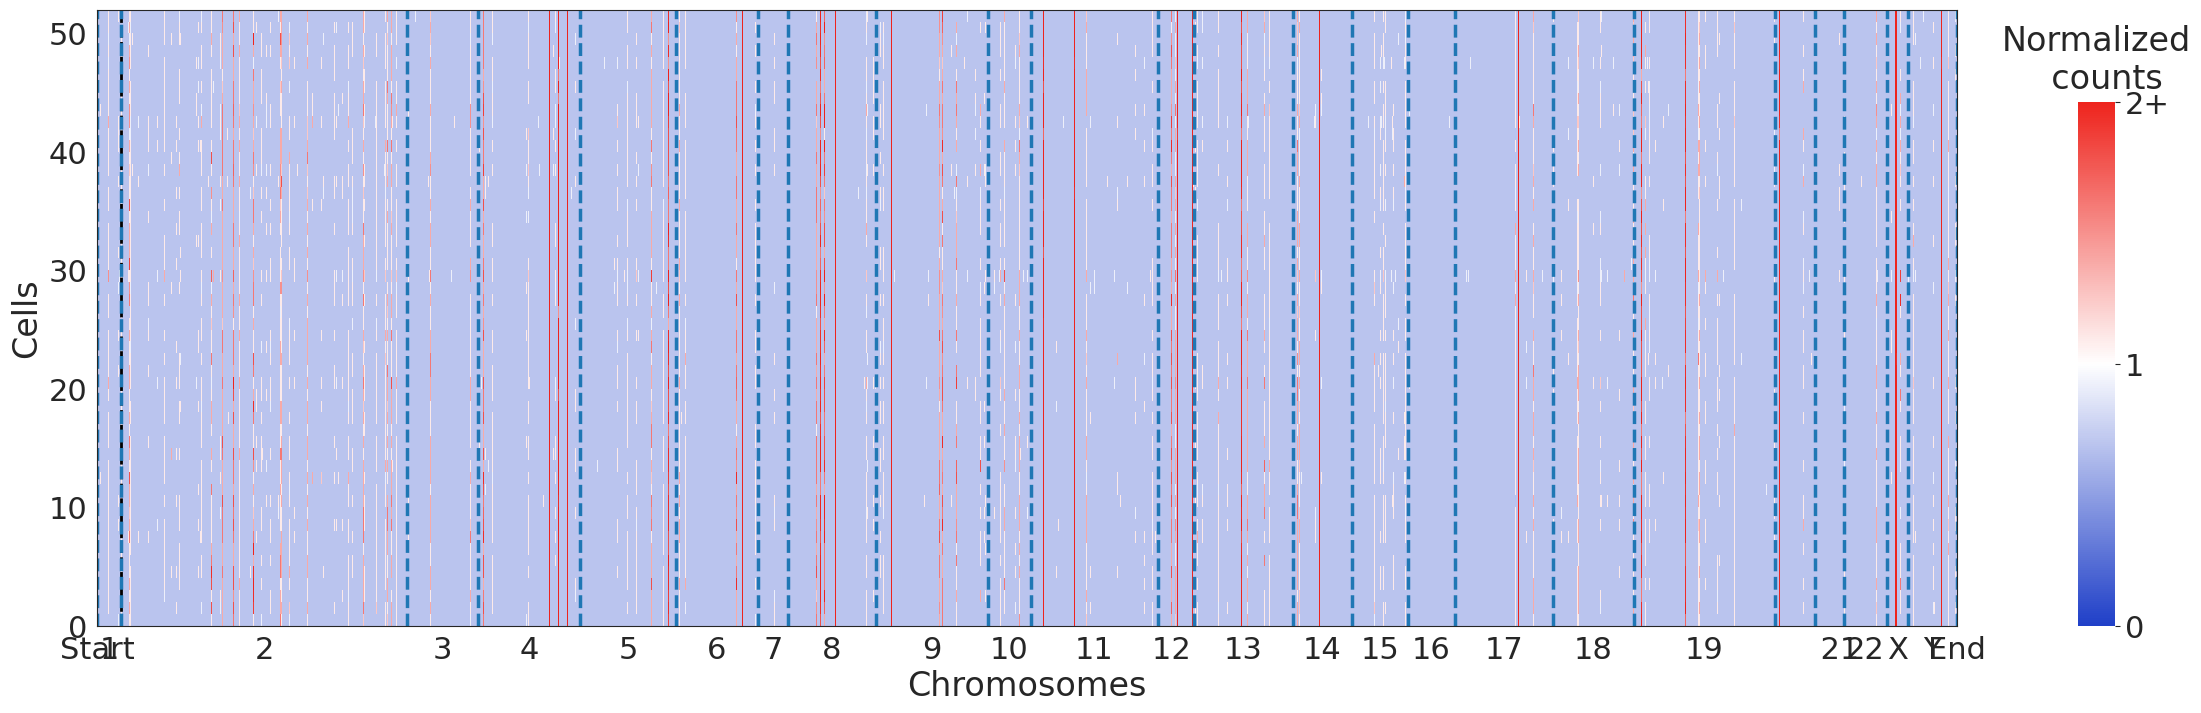

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=1.66519e-08
n_regions: 26
nlopt failed: bounds 0 fail 0 <= -0.000349177 <= inf
nlopt failed: bounds 0 fail 0 <= -0.167412 <= inf
nlopt failed: bounds 0 fail 0 <= -0.0267067 <= inf
An error occurred while processing the cluster file: 'segmented_regions'


In [ ]:
for cluster_file in [cluster_file_1, cluster_file_2,cluster_file_3, cluster_file_4,
                     cluster_file_5, cluster_file_6, cluster_file_7]:
    try:
        adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
        data = adata.X
        # Run SCICoNE analysis
        bps = sci.detect_breakpoints(data=data, window_size=200, threshold=3, input_breakpoints=chromosome_stops_list)

        # Save the matrix plot
        matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
        
        scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                        chr_stops_dict=chromosome_stops,
                                        cbar_title='Normalized\n  counts', vmax=2, cluster=False)

        # plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
        # plt.close()

        # Learn and save the tree plot
        
        # inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
        # inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

        # tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}.png"
        # Render the tree plot using graphviz's render method

        # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
        # print(f"Tree plot saved to {tree_plot_filename}.png")

    except ValueError as ve:
        print(f"ValueError while processing the cluster file: {ve}")
    except Exception as e:
        print(f"An error occurred while processing the cluster file: {e}")
        continue


In [ ]:
cluster_file = 'clusters_mean'
adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
data = adata.X
# Run SCICoNE analysis
bps = sci.detect_breakpoints(data=data, window_size=350, threshold=3, input_breakpoints=chromosome_stops_list)

        # Save the matrix plot
matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                chr_stops_dict=chromosome_stops,
                                cbar_title='Normalized\n  counts', vmax=2, cluster=False)


min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 7.79114
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157,

==57091==ERROR: AddressSanitizer: heap-buffer-overflow on address 0x7f776947f7f8 at pc 0x55aee72fa1e7 bp 0x7ffd23c096d0 sp 0x7ffd23c096c0
WRITE of size 8 at 0x7f776947f7f8 thread T0
    #0 0x55aee72fa1e6 in main (/home/andress/pylabs/SCICoNE_lab/build/breakpoint_detection+0x1d1e6) (BuildId: 955cdf7c3e082f240cb00b4ce9cd736c84f904f9)
    #1 0x7f776c8901c9  (/lib/x86_64-linux-gnu/libc.so.6+0x2a1c9) (BuildId: 42c84c92e6f98126b3e2230ebfdead22c235b667)
    #2 0x7f776c89028a in __libc_start_main (/lib/x86_64-linux-gnu/libc.so.6+0x2a28a) (BuildId: 42c84c92e6f98126b3e2230ebfdead22c235b667)
    #3 0x55aee72f18f4 in _start (/home/andress/pylabs/SCICoNE_lab/build/breakpoint_detection+0x148f4) (BuildId: 955cdf7c3e082f240cb00b4ce9cd736c84f904f9)

0x7f776947f7f8 is located 8 bytes before 262144-byte region [0x7f776947f800,0x7f77694bf800)
allocated by thread T0 here:
    #0 0x7f776d00c548 in operator new(unsigned long) ../../../../src/libsanitizer/asan/asan_new_delete.cpp:95
    #1 0x55aee733fc0b in s

KeyError: 'segmented_regions'